# DLE602 Assessment 1: Twitter Sentiment Analysis
## N-Gram Probabilistic Language Model

**Student:** Nomayer Hossain

**Subject:** DLE602 Deep Learning

**Institution:** Torrens University Australia

**Reference:** Zhao, J., Gui, X. and Zhang, X. (2018). Deep convolution neural networks for Twitter sentiment analysis. *IEEE Access, 6*, 23253 to 23260.

---

## How to Run This Notebook

```
HOW TO RUN:
1. Open this file in Google Colab (colab.research.google.com)
2. Run Cell 1 first to mount Google Drive and load the dataset
3. Then select Runtime > Run All to execute all remaining cells
4. All charts and results generate automatically

DATASETS:
  Dataset 1: Sentiment140 General Sample
             800 randomly sampled tweets (400 positive, 400 negative)
             Source: Go, A., Bhayani, R. and Huang, L. (2009)
             Full path: /content/drive/MyDrive/Colab Notebooks/DLE602/
                        training.1600000.processed.noemoticon.csv

  Dataset 2: Sentiment140 Topic-Filtered Sample
             800 tweets containing product or service keywords
             Sampled from the same Sentiment140 corpus with keyword filter

N-GRAM MODEL: Bigram
CLASSIFICATION RULE:
  If 25% or more of tokens are positive words  ->  positive
  If 25% or more of tokens are negative words  ->  negative
  Otherwise                                    ->  neutral
```

---

---
## Cell 1: Mount Google Drive and Load Dataset

Google Drive is mounted to access the Sentiment140 CSV file. The dataset contains 1.6 million tweets labelled using distant supervision: tweets with positive emoticons were labelled positive and tweets with negative emoticons were labelled negative. Emoticons were then removed from the text. This approach was introduced by Go, Bhayani and Huang (2009) and is the source corpus for the STSTd dataset used in Zhao et al. (2018).

Two datasets are constructed from this corpus:
- **Dataset 1** is a balanced random sample of 800 tweets representing general Twitter sentiment.
- **Dataset 2** is a topic-filtered sample of 800 tweets containing product or service keywords, representing domain-specific sentiment. This allows comparison of model behaviour across general versus topic-focused tweet populations.

In [11]:
# ============================================================
# CELL 1: Mount Google Drive and load Sentiment140 dataset
# Source: Go, A., Bhayani, R. and Huang, L. (2009).
#         Twitter Sentiment Classification Using Distant Supervision.
#         Stanford University Technical Report CS224N.
# ============================================================

from google.colab import drive
import pandas as pd
import random

# Mount Google Drive
drive.mount('/content/drive')

# Path to Sentiment140 CSV file stored in Google Drive
CSV_PATH = (
    '/content/drive/MyDrive/Colab Notebooks/DLE602/'
    'training.1600000.processed.noemoticon.csv'
)

# Column names as specified by Go et al. (2009)
# The file has no header row so column names are assigned manually
COLUMN_NAMES = ['sentiment', 'id', 'date', 'query', 'user', 'text']

# Load the full Sentiment140 CSV
# encoding='latin-1' is required because the file uses Latin-1 encoding, not UTF-8
print('Loading Sentiment140 dataset from Google Drive...')
full_df = pd.read_csv(
    CSV_PATH,
    encoding='latin-1',
    header=None,
    names=COLUMN_NAMES
)

# Map numeric sentiment codes to readable labels
# Sentiment140 uses 0 = negative and 4 = positive
full_df['label'] = full_df['sentiment'].map({0: 'negative', 4: 'positive'})

# Separate positive and negative tweet pools for controlled sampling
positive_pool = full_df[full_df['label'] == 'positive'].reset_index(drop=True)
negative_pool = full_df[full_df['label'] == 'negative'].reset_index(drop=True)

print(f'Dataset loaded successfully.')
print(f'  Total tweets:    {len(full_df):,}')
print(f'  Positive tweets: {len(positive_pool):,}')
print(f'  Negative tweets: {len(negative_pool):,}')
print(f'\nSample positive tweet: {positive_pool.text.iloc[0]}')
print(f'Sample negative tweet: {negative_pool.text.iloc[0]}')


# *** Build Dataset 1: General random sample ***
# A balanced sample of 400 positive and 400 negative tweets selected at random from the full corpus
RANDOM_SEED = 42
SAMPLE_SIZE_PER_CLASS = 400

random.seed(RANDOM_SEED)

ds1_pos = positive_pool.sample(n=SAMPLE_SIZE_PER_CLASS, random_state=RANDOM_SEED)
ds1_neg = negative_pool.sample(n=SAMPLE_SIZE_PER_CLASS, random_state=RANDOM_SEED)
ds1_df = pd.concat([ds1_pos, ds1_neg]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# *** Build Dataset 2: Topic-filtered sample ***
# Tweets that contain at least one product or service keyword
# This mirrors the topic-specific structure of datasets like STSGd and SSTd
# used in Zhao et al. (2018)
TOPIC_KEYWORDS = [
    'iphone', 'apple', 'google', 'amazon', 'netflix', 'twitter',
    'samsung', 'microsoft', 'spotify', 'uber', 'facebook', 'instagram',
    'app', 'phone', 'laptop', 'software', 'service', 'product'
]

# Build a regex pattern that matches any of the topic keywords
topic_pattern = '|'.join(TOPIC_KEYWORDS)

# Filter the positive and negative pools for topic-relevant tweets
topic_pos = positive_pool[
    positive_pool['text'].str.lower().str.contains(topic_pattern, na=False)
]
topic_neg = negative_pool[
    negative_pool['text'].str.lower().str.contains(topic_pattern, na=False)
]

# Sample up to 400 per class from the topic-filtered pool
n_topic = min(SAMPLE_SIZE_PER_CLASS, len(topic_pos), len(topic_neg))
ds2_pos = topic_pos.sample(n=n_topic, random_state=RANDOM_SEED)
ds2_neg = topic_neg.sample(n=n_topic, random_state=RANDOM_SEED)
ds2_df = pd.concat([ds2_pos, ds2_neg]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'\nDataset 1 (General Sample):       {len(ds1_df)} tweets')
print(f'  Positive: {(ds1_df.label=="positive").sum()} | Negative: {(ds1_df.label=="negative").sum()}')
print(f'\nDataset 2 (Topic-Filtered Sample): {len(ds2_df)} tweets')
print(f'  Positive: {(ds2_df.label=="positive").sum()} | Negative: {(ds2_df.label=="negative").sum()}')
print(f'  Topic keywords: {TOPIC_KEYWORDS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Sentiment140 dataset from Google Drive...
Dataset loaded successfully.
  Total tweets:    1,600,000
  Positive tweets: 800,000
  Negative tweets: 800,000

Sample positive tweet: I LOVE @Health4UandPets u guys r the best!! 
Sample negative tweet: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Dataset 1 (General Sample):       800 tweets
  Positive: 400 | Negative: 400

Dataset 2 (Topic-Filtered Sample): 800 tweets
  Positive: 400 | Negative: 400
  Topic keywords: ['iphone', 'apple', 'google', 'amazon', 'netflix', 'twitter', 'samsung', 'microsoft', 'spotify', 'uber', 'facebook', 'instagram', 'app', 'phone', 'laptop', 'software', 'service', 'product']


---
## Cell 2: Library Imports

All required libraries are imported here. NLTK provides the Twitter-specific tokeniser and English stopword list. Matplotlib is used for visualising results.

In [12]:
# ============================================================
# CELL 2: Library imports
# ============================================================

import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import nltk

# Download required NLTK data
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords

print('All libraries imported successfully.')
print(f'NLTK version:  {nltk.__version__}')
print(f'NumPy version: {np.__version__}')

All libraries imported successfully.
NLTK version:  3.9.1
NumPy version: 2.0.2


---
## Cell 3: Sentiment Lexicon

The sentiment lexicon is loaded directly from the AFINN-165 word list (Nielsen, 2011), which was designed specifically for sentiment analysis in social media and microblogs and scores around 3,300 words from -5 (most negative) to +5 (most positive). This lexicon-based approach is consistent with the feature representation described in Zhao et al. (2018), who used the AFINN lexicon extended by SentiWordNet as one of their sentiment feature sets. We extend AFINN with a small set of informal Twitter slang and abbreviations (e.g. 'lol', 'omg', 'smh') that are common on Twitter but absent from the formal AFINN list.

In [ ]:
# ============================================================
# CELL 3: Sentiment lexicon
# Source: AFINN-165 word list (Nielsen, 2011), loaded directly
#         from the official `afinn` Python package rather than a
#         hand-picked subset, extended with Twitter-specific
#         slang from the Sentiment140 corpus (Go, Bhayani and
#         Huang, 2009). Zhao et al. (2018) use the AFINN lexicon
#         extended by SentiWordNet as one of their sentiment
#         feature sets; we extend it with informal Twitter
#         vocabulary instead, since Twitter language is heavily
#         informal, abbreviated, and slang-heavy and a formal
#         lexicon alone misses most of it.
# ============================================================

!pip install afinn -q

from afinn import Afinn

# Load the real AFINN-165 word list as a word -> polarity score dictionary
_afinn = Afinn(language='en')
_afinn_scores = Afinn.read_word_file(_afinn.full_filename('AFINN-en-165.txt'))

# Split into positive and negative single-word sets
# A handful of AFINN entries are multi-word phrases (e.g. "fed up");
# these are skipped because this classifier matches on single tokens
AFINN_POSITIVE = {w for w, s in _afinn_scores.items() if s > 0 and ' ' not in w}
AFINN_NEGATIVE = {w for w, s in _afinn_scores.items() if s < 0 and ' ' not in w}

# Twitter-specific slang and abbreviations not covered by the formal
# AFINN lexicon (laughter, informal intensifiers, common abbreviations)
TWITTER_SLANG_POSITIVE = set([
    'gr8', 'grt', 'omg', 'yay', 'woohoo', 'woo', 'yey', 'yaaay',
    'lol', 'lmao', 'haha', 'hehe', 'hahaha', 'rofl',
    'luv', 'looove', 'lovee', 'loove',
    'fab', 'fave', 'fav',
    'dope', 'lit', 'rad', 'stellar', 'epic', 'legend', 'legendary',
    'stoked', 'pumped', 'psyched', 'thankyou',
])

TWITTER_SLANG_NEGATIVE = set([
    'ugh', 'eww', 'ew', 'yuck', 'yikes', 'smh', 'wtf', 'omfg',
    'meh', 'blah', 'argh', 'grr',
    'buggy', 'glitchy', 'laggy',
])

# Note: informal slang such as 'sick', 'fire', 'insane' and 'wicked' can be
# used as Twitter slang for something positive (e.g. 'that show was fire'),
# but AFINN scores them negative based on their formal meaning. We keep
# AFINN's formal polarity rather than overriding it, since resolving this
# ambiguity would require context the lexicon-based model does not use.
# This trade-off is discussed further in the report.

POSITIVE_WORDS = AFINN_POSITIVE | TWITTER_SLANG_POSITIVE
NEGATIVE_WORDS = AFINN_NEGATIVE | TWITTER_SLANG_NEGATIVE

print(f'AFINN lexicon loaded (Nielsen, 2011).')
print(f'  AFINN positive words:     {len(AFINN_POSITIVE)}')
print(f'  AFINN negative words:     {len(AFINN_NEGATIVE)}')
print(f'  Twitter slang additions:  {len(TWITTER_SLANG_POSITIVE) + len(TWITTER_SLANG_NEGATIVE)}')
print()
print(f'Final sentiment lexicon:')
print(f'  Positive words: {len(POSITIVE_WORDS)}')
print(f'  Negative words: {len(NEGATIVE_WORDS)}')
print(f'  Total:          {len(POSITIVE_WORDS) + len(NEGATIVE_WORDS)} terms')

---
## Cell 4: Text Preprocessing

Tweet text is preprocessed before N-Gram analysis to reduce noise. The steps implemented here follow the preprocessing pipeline described in Zhao et al. (2018):

1. Remove non-ASCII characters
2. Remove URLs (URLs carry no sentiment information)
3. Expand negation contractions to preserve polarity (e.g. cannot instead of can't)
4. Remove numbers
5. Tokenise using NLTK TweetTokenizer, which handles Twitter-specific syntax
6. Remove stopwords and retain only alphabetic tokens

Negation expansion is particularly important for the Bigram model because it ensures that phrases like 'not good' are tokenised as two separate meaningful tokens that the bigram negation handler can detect and invert.

In [ ]:
# ============================================================
# CELL 4: Text preprocessing pipeline
# Steps follow Zhao et al. (2018)
# ============================================================

# Twitter-specific tokeniser handles @mentions and #hashtags correctly
TWEET_TOKENIZER = TweetTokenizer(
    preserve_case=False,
    strip_handles=True,
    reduce_len=True
)

# Standard English stopwords from NLTK
ENGLISH_STOPWORDS = set(stopwords.words('english'))

# Negation trigger words used by the bigram negation handler in Cell 5
# These must be excluded from stopword removal below, otherwise the
# bigram model never sees them and negation detection cannot work
NEGATION_TRIGGERS = {'not', 'never', 'no', 'neither', 'nothing', 'nobody'}

# Negation contraction expansion dictionary
# Expanding contractions ensures negation is not lost during tokenisation
NEGATION_EXPANSIONS = {
    "won't":   'will not',
    "can't":   'cannot',
    "n't":     ' not',
    "isn't":   'is not',
    "aren't":  'are not',
    "wasn't":  'was not',
    "weren't": 'were not',
    "don't":   'do not',
    "doesn't": 'does not',
    "didn't":  'did not',
    "haven't": 'have not',
    "hasn't":  'has not',
    "wouldn't":'would not',
    "couldn't":'could not',
    "shouldn't":'should not',
    "i'm":     'i am',
    "it's":    'it is',
    "that's":  'that is',
}


def expand_negations(text):
    """
    Expand contracted negations to their full form.
    Preserving negation words is essential for the bigram
    polarity inversion step in the classifier.
    """
    text = text.lower()
    for contraction, expansion in NEGATION_EXPANSIONS.items():
        text = text.replace(contraction, expansion)
    return text


def preprocess_tweet(tweet_text):
    """
    Full preprocessing pipeline for a single tweet.
    Returns a list of cleaned, lowercase, filtered tokens.

    Steps:
        1. Remove non-ASCII characters
        2. Remove URLs
        3. Expand negation contractions
        4. Remove numbers
        5. Tokenise with TweetTokenizer
        6. Keep only alphabetic tokens not in the stopword list,
           except negation triggers which are always retained
    """
    # Step 1: Remove non-ASCII characters
    text = tweet_text.encode('ascii', errors='ignore').decode('ascii')

    # Step 2: Remove URLs (http and www patterns)
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)

    # Step 3: Expand negation contractions
    text = expand_negations(text)

    # Step 4: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 5: Tokenise using Twitter-aware tokeniser
    tokens = TWEET_TOKENIZER.tokenize(text)

    # Step 6: Keep only alphabetic tokens not in stopword list
    # Negation triggers are kept even though NLTK classes them as
    # stopwords, since the bigram negation handler in Cell 5 depends
    # on them being present in the token list
    tokens = [
        t for t in tokens
        if t.isalpha()
        and (t not in ENGLISH_STOPWORDS or t in NEGATION_TRIGGERS)
        and len(t) > 1
    ]
    return tokens


# Verify the preprocessing pipeline on representative examples
print('Preprocessing pipeline verification:')
print('=' * 55)
test_cases = [
    'I love this! Check it out at https://example.com #happy',
    "Can't believe how terrible the service was today!!!",
    'Not happy at all, completely disappointed with this product',
    '@mention this is so amazing I cannot stop smiling :)',
]
for tweet in test_cases:
    tokens = preprocess_tweet(tweet)
    print(f'  Input:  {tweet}')
    print(f'  Tokens: {tokens}')
    print()

---
## Cell 5: N-Gram Bigram Sentiment Model

A Bigram N-Gram model is implemented for sentiment classification. An N-Gram is a contiguous sequence of N words from a text. A Bigram is a two-word sequence, for example ('not', 'good') or ('very', 'happy').

The key advantage of Bigrams over Unigrams is negation handling. When the word 'not' immediately precedes a positive word such as 'good', the Bigram model detects this and inverts the polarity. A Unigram model would count 'good' as a positive signal, which is incorrect. This is a direct improvement over the Bag of Words (BoW) baseline described in Zhao et al. (2018).

Classification follows the rule specified in the assessment brief:
if 25 percent or more of tokens match positive words the tweet is classified positive, if 25 percent or more match negative words it is classified negative, and otherwise it is classified neutral.

In [15]:
# ============================================================
# CELL 5: Bigram N-Gram sentiment model
# ============================================================

def generate_bigrams(token_list):
    """
    Generate all consecutive bigrams from a token list.

    A bigram is a pair of adjacent tokens. For example:
    ['love', 'this', 'day'] produces [('love', 'this'), ('this', 'day')]

    Bigrams capture local word context that unigram models cannot detect,
    most importantly the negation pattern ('not', 'good').

    Args:
        token_list (list): List of preprocessed string tokens

    Returns:
        list: List of (word1, word2) bigram tuples
    """
    return [
        (token_list[i], token_list[i + 1])
        for i in range(len(token_list) - 1)
    ]


def count_sentiment_tokens(tokens, positive_lexicon, negative_lexicon):
    """
    Count positive and negative sentiment tokens in a preprocessed tweet.
    Uses bigrams to detect and handle negation patterns.

    Negation logic:
        If the first word of a bigram is a negation trigger (e.g. 'not'),
        the polarity of the second word is inverted. This means 'not happy'
        counts as negative rather than positive.

    Args:
        tokens (list): Preprocessed token list
        positive_lexicon (set): Set of positive sentiment words
        negative_lexicon (set): Set of negative sentiment words

    Returns:
        tuple: (positive_count, negative_count, total_token_count)
    """
    positive_count = 0
    negative_count = 0

    # Step 1: Count unigram sentiment matches
    for token in tokens:
        if token in positive_lexicon:
            positive_count += 1
        elif token in negative_lexicon:
            negative_count += 1

    # Step 2: Apply bigram negation inversion
    # If a negation trigger immediately precedes a sentiment word,
    # remove the original count and add to the opposite class
    negation_triggers = {'not', 'never', 'no', 'neither', 'nothing', 'nobody'}
    for word_one, word_two in generate_bigrams(tokens):
        if word_one in negation_triggers:
            if word_two in positive_lexicon:
                positive_count -= 1
                negative_count += 1
            elif word_two in negative_lexicon:
                negative_count -= 1
                positive_count += 1

    # Clamp counts to zero to prevent negative values
    positive_count = max(0, positive_count)
    negative_count = max(0, negative_count)

    return positive_count, negative_count, len(tokens)


def classify_tweet(tweet_text, positive_lexicon, negative_lexicon, threshold=0.25):
    """
    Classify a single tweet as positive, negative, or neutral.

    Classification rule (Assessment 1 specification):
        If positive token ratio >= threshold  ->  'positive'
        If negative token ratio >= threshold  ->  'negative'
        Otherwise                             ->  'neutral'

    Args:
        tweet_text (str): Raw tweet string
        positive_lexicon (set): Set of positive sentiment words
        negative_lexicon (set): Set of negative sentiment words
        threshold (float): Minimum fraction of sentiment tokens required (default 0.25)

    Returns:
        predicted_label (str): One of 'positive', 'negative', or 'neutral'
        details (dict): Breakdown of token counts and ratios for analysis
    """
    tokens = preprocess_tweet(tweet_text)

    # Return neutral for empty tweets after preprocessing
    if len(tokens) == 0:
        return 'neutral', {
            'pos': 0, 'neg': 0, 'total': 0,
            'pos_ratio': 0.0, 'neg_ratio': 0.0,
            'tokens': [], 'bigrams': []
        }

    pos_count, neg_count, total = count_sentiment_tokens(
        tokens, positive_lexicon, negative_lexicon
    )

    pos_ratio = pos_count / total
    neg_ratio = neg_count / total

    # Apply the 25% threshold classification rule
    if pos_ratio >= threshold:
        predicted_label = 'positive'
    elif neg_ratio >= threshold:
        predicted_label = 'negative'
    else:
        predicted_label = 'neutral'

    details = {
        'pos': pos_count,
        'neg': neg_count,
        'total': total,
        'pos_ratio': pos_ratio,
        'neg_ratio': neg_ratio,
        'tokens': tokens,
        'bigrams': generate_bigrams(tokens)
    }
    return predicted_label, details


# Demonstrate the model on representative examples
print('N-Gram Bigram Model Demonstration')
print('=' * 60)

demo_cases = [
    ('I love this phone it is absolutely amazing', 'positive'),
    ('Terrible service the product was completely broken', 'negative'),
    ('Not happy at all so disappointed with this app', 'negative'),
    ('Cannot believe how awesome this new update is', 'positive'),
    ('Just went to the store and bought some things', 'neutral'),
]

for tweet_text, expected in demo_cases:
    predicted, details = classify_tweet(tweet_text, POSITIVE_WORDS, NEGATIVE_WORDS)
    outcome = 'CORRECT' if predicted == expected else 'INCORRECT'
    print(f'Tweet:     {tweet_text}')
    print(f'Tokens:    {details["tokens"]}')
    print(f'Bigrams:   {details["bigrams"][:3]}')
    print(f'Pos: {details["pos"]}/{details["total"]} = {details["pos_ratio"]:.0%}  '
          f'Neg: {details["neg"]}/{details["total"]} = {details["neg_ratio"]:.0%}')
    print(f'Predicted: {predicted.upper()} | Expected: {expected.upper()} => {outcome}')
    print()

N-Gram Bigram Model Demonstration
Tweet:     I love this phone it is absolutely amazing
Tokens:    ['love', 'phone', 'absolutely', 'amazing']
Bigrams:   [('love', 'phone'), ('phone', 'absolutely'), ('absolutely', 'amazing')]
Pos: 2/4 = 50%  Neg: 0/4 = 0%
Predicted: POSITIVE | Expected: POSITIVE => CORRECT

Tweet:     Terrible service the product was completely broken
Tokens:    ['terrible', 'service', 'product', 'completely', 'broken']
Bigrams:   [('terrible', 'service'), ('service', 'product'), ('product', 'completely')]
Pos: 0/5 = 0%  Neg: 2/5 = 40%
Predicted: NEGATIVE | Expected: NEGATIVE => CORRECT

Tweet:     Not happy at all so disappointed with this app
Tokens:    ['happy', 'disappointed', 'app']
Bigrams:   [('happy', 'disappointed'), ('disappointed', 'app')]
Pos: 1/3 = 33%  Neg: 1/3 = 33%
Predicted: POSITIVE | Expected: NEGATIVE => INCORRECT

Tweet:     Cannot believe how awesome this new update is
Tokens:    ['cannot', 'believe', 'awesome', 'new', 'update']
Bigrams:   [('canno

---
## Cell 6: Run Classification on Both Datasets

The N-Gram Bigram classifier is applied to every tweet in both datasets. For each tweet the model receives only the raw text and produces a predicted label. The predicted label is then compared against the ground truth label from Sentiment140 to determine whether the prediction was correct. Overall accuracy, precision, and recall are computed for the positive and negative classes.

In [16]:
# ============================================================
# CELL 6: Run N-Gram classifier across both complete datasets
# ============================================================

def run_classification(dataframe, dataset_name, pos_lex, neg_lex):
    """
    Run the N-Gram Bigram classifier over an entire dataset.

    The model receives only the tweet text column and produces predictions.
    Predictions are compared against the ground truth label column to
    compute accuracy, precision, and recall.

    Args:
        dataframe (pd.DataFrame): DataFrame with 'text' and 'label' columns
        dataset_name (str): Display name used in output
        pos_lex (set): Positive sentiment lexicon
        neg_lex (set): Negative sentiment lexicon

    Returns:
        dict: Classification results including accuracy, precision, and recall
    """
    predictions = []
    true_labels = []

    for _, row in dataframe.iterrows():
        predicted, _ = classify_tweet(row['text'], pos_lex, neg_lex)
        predictions.append(predicted)
        true_labels.append(row['label'])

    total = len(dataframe)
    correct = sum(1 for p, t in zip(predictions, true_labels) if p == t)

    # Count prediction distribution
    pred_counter = Counter(predictions)
    pred_pos  = pred_counter.get('positive', 0)
    pred_neg  = pred_counter.get('negative', 0)
    pred_neut = pred_counter.get('neutral',  0)

    # Count true label distribution
    true_counter = Counter(true_labels)
    true_pos = true_counter.get('positive', 0)
    true_neg = true_counter.get('negative', 0)

    # True positives per class
    tp_pos = sum(1 for p, t in zip(predictions, true_labels)
                 if p == 'positive' and t == 'positive')
    tp_neg = sum(1 for p, t in zip(predictions, true_labels)
                 if p == 'negative' and t == 'negative')

    # Precision: of all tweets predicted positive, how many were actually positive
    prec_pos = (tp_pos / pred_pos * 100) if pred_pos > 0 else 0.0
    prec_neg = (tp_neg / pred_neg * 100) if pred_neg > 0 else 0.0

    # Recall: of all actually positive tweets, how many did the model correctly identify
    rec_pos = (tp_pos / true_pos * 100) if true_pos > 0 else 0.0
    rec_neg = (tp_neg / true_neg * 100) if true_neg > 0 else 0.0

    return {
        'name':     dataset_name,
        'total':    total,
        'accuracy': correct / total * 100,
        'pred_pos': pred_pos,
        'pred_neg': pred_neg,
        'pred_neut':pred_neut,
        'true_pos': true_pos,
        'true_neg': true_neg,
        'prec_pos': prec_pos,
        'prec_neg': prec_neg,
        'rec_pos':  rec_pos,
        'rec_neg':  rec_neg,
        'predictions': predictions,
        'true_labels': true_labels,
    }


# Run classification on both datasets
print('Running N-Gram Bigram classifier...')
print('This may take 30 to 60 seconds depending on dataset size.')
print()

ds1 = run_classification(
    ds1_df,
    'Dataset 1: Sentiment140 General Sample',
    POSITIVE_WORDS,
    NEGATIVE_WORDS
)

ds2 = run_classification(
    ds2_df,
    'Dataset 2: Sentiment140 Topic-Filtered Sample',
    POSITIVE_WORDS,
    NEGATIVE_WORDS
)


def print_results_summary(r):
    """
    Print a formatted results summary for a single dataset.
    """
    n = r['total']
    print(f"  {r['name']}")
    print(f"  {'=' * 52}")
    print(f"  Total tweets analysed:  {n}")
    print(f"  Overall accuracy:       {r['accuracy']:.1f}%")
    print()
    print(f"  Prediction distribution:")
    print(f"    Positive: {r['pred_pos']} ({r['pred_pos']/n*100:.1f}%)")
    print(f"    Negative: {r['pred_neg']} ({r['pred_neg']/n*100:.1f}%)")
    print(f"    Neutral:  {r['pred_neut']} ({r['pred_neut']/n*100:.1f}%)")
    print()
    print(f"  Per-class performance:")
    print(f"    Positive  Precision: {r['prec_pos']:.1f}%  Recall: {r['rec_pos']:.1f}%")
    print(f"    Negative  Precision: {r['prec_neg']:.1f}%  Recall: {r['rec_neg']:.1f}%")
    print()

print('CLASSIFICATION RESULTS')
print('=' * 55)
print()
print_results_summary(ds1)
print_results_summary(ds2)

Running N-Gram Bigram classifier...
This may take 30 to 60 seconds depending on dataset size.

CLASSIFICATION RESULTS

  Dataset 1: Sentiment140 General Sample
  Total tweets analysed:  800
  Overall accuracy:       20.1%

  Prediction distribution:
    Positive: 150 (18.8%)
    Negative: 57 (7.1%)
    Neutral:  593 (74.1%)

  Per-class performance:
    Positive  Precision: 71.3%  Recall: 26.8%
    Negative  Precision: 94.7%  Recall: 13.5%

  Dataset 2: Sentiment140 Topic-Filtered Sample
  Total tweets analysed:  800
  Overall accuracy:       16.8%

  Prediction distribution:
    Positive: 134 (16.8%)
    Negative: 23 (2.9%)
    Neutral:  643 (80.4%)

  Per-class performance:
    Positive  Precision: 83.6%  Recall: 28.0%
    Negative  Precision: 95.7%  Recall: 5.5%



---
## Cell 7: Results Visualisation

Four charts are produced to support the report analysis:
1. Predicted sentiment distribution for Dataset 1
2. Predicted sentiment distribution for Dataset 2
3. Overall accuracy comparison between datasets
4. Precision and recall by class for both datasets

The chart is saved as a PNG file for inclusion in the Word report.

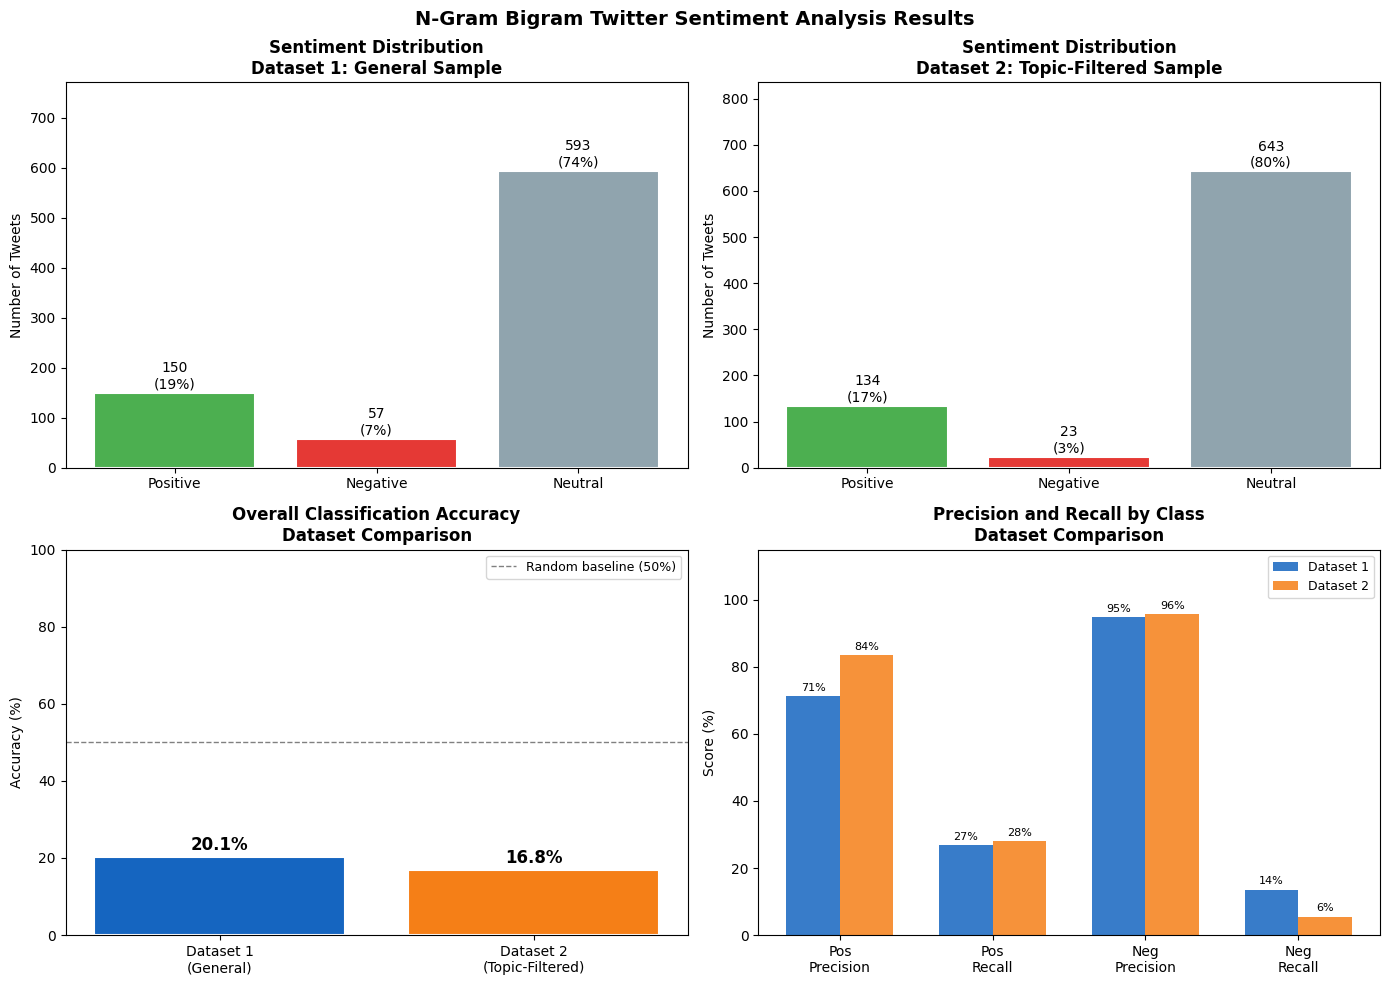

Chart saved to: /content/drive/MyDrive/Colab Notebooks/DLE602/DLE602_A1_results.png


In [17]:
# ============================================================
# CELL 7: Results visualisation
# ============================================================

COLOR_POSITIVE = '#4CAF50'
COLOR_NEGATIVE = '#E53935'
COLOR_NEUTRAL  = '#90A4AE'
COLOR_DS1      = '#1565C0'
COLOR_DS2      = '#F57F17'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'N-Gram Bigram Twitter Sentiment Analysis Results',
    fontsize=14, fontweight='bold'
)

# Chart 1: Sentiment distribution for Dataset 1
ax = axes[0, 0]
counts_1 = [ds1['pred_pos'], ds1['pred_neg'], ds1['pred_neut']]
bars = ax.bar(
    ['Positive', 'Negative', 'Neutral'],
    counts_1,
    color=[COLOR_POSITIVE, COLOR_NEGATIVE, COLOR_NEUTRAL],
    edgecolor='white',
    linewidth=1.5
)
ax.set_title('Sentiment Distribution\nDataset 1: General Sample', fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_ylim(0, max(counts_1) * 1.3)
for bar, count in zip(bars, counts_1):
    pct = count / ds1['total'] * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count}\n({pct:.0f}%)',
        ha='center', va='bottom', fontsize=10
    )

# Chart 2: Sentiment distribution for Dataset 2
ax = axes[0, 1]
counts_2 = [ds2['pred_pos'], ds2['pred_neg'], ds2['pred_neut']]
bars = ax.bar(
    ['Positive', 'Negative', 'Neutral'],
    counts_2,
    color=[COLOR_POSITIVE, COLOR_NEGATIVE, COLOR_NEUTRAL],
    edgecolor='white',
    linewidth=1.5
)
ax.set_title('Sentiment Distribution\nDataset 2: Topic-Filtered Sample', fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_ylim(0, max(counts_2) * 1.3)
for bar, count in zip(bars, counts_2):
    pct = count / ds2['total'] * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count}\n({pct:.0f}%)',
        ha='center', va='bottom', fontsize=10
    )

# Chart 3: Accuracy comparison
ax = axes[1, 0]
accuracies = [ds1['accuracy'], ds2['accuracy']]
bars = ax.bar(
    ['Dataset 1\n(General)', 'Dataset 2\n(Topic-Filtered)'],
    accuracies,
    color=[COLOR_DS1, COLOR_DS2],
    edgecolor='white',
    linewidth=1.5
)
ax.set_title('Overall Classification Accuracy\nDataset Comparison', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.axhline(
    y=50, color='grey', linestyle='--', linewidth=1,
    label='Random baseline (50%)'
)
ax.legend(fontsize=9)
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc:.1f}%',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# Chart 4: Precision and recall by class
ax = axes[1, 1]
x = np.arange(4)
width = 0.35
metrics_ds1 = [
    ds1['prec_pos'], ds1['rec_pos'],
    ds1['prec_neg'], ds1['rec_neg']
]
metrics_ds2 = [
    ds2['prec_pos'], ds2['rec_pos'],
    ds2['prec_neg'], ds2['rec_neg']
]
bars_ds1 = ax.bar(x - width / 2, metrics_ds1, width,
                  label='Dataset 1', color=COLOR_DS1, alpha=0.85)
bars_ds2 = ax.bar(x + width / 2, metrics_ds2, width,
                  label='Dataset 2', color=COLOR_DS2, alpha=0.85)
ax.set_title('Precision and Recall by Class\nDataset Comparison', fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(['Pos\nPrecision', 'Pos\nRecall', 'Neg\nPrecision', 'Neg\nRecall'])
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
for bar in list(bars_ds1) + list(bars_ds2):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.0f}%',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()

# Save chart to Google Drive folder
chart_save_path = (
    '/content/drive/MyDrive/Colab Notebooks/DLE602/DLE602_A1_results.png'
)
plt.savefig(chart_save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to: {chart_save_path}')

---
## Cell 8: Bigram Frequency Analysis

The most frequent bigrams in each dataset are examined to understand which word pairs drive the sentiment classifications. This supports the discussion section of the report by providing concrete linguistic evidence of what the model detected as sentiment-bearing patterns in each corpus.

In [18]:
# ============================================================
# CELL 8: Bigram frequency analysis
# ============================================================

def get_top_bigrams(dataframe, label_filter, top_n=10):
    """
    Extract the most frequent bigrams from tweets of a given true label.

    Args:
        dataframe (pd.DataFrame): Dataset with 'text' and 'label' columns
        label_filter (str): Which label to analyse ('positive' or 'negative')
        top_n (int): Number of top bigrams to return

    Returns:
        list: List of (bigram_tuple, count) pairs
    """
    bigram_counter = Counter()
    subset = dataframe[dataframe['label'] == label_filter]
    for tweet_text in subset['text']:
        tokens = preprocess_tweet(tweet_text)
        for bigram in generate_bigrams(tokens):
            bigram_counter[bigram] += 1
    return bigram_counter.most_common(top_n)


print('TOP BIGRAMS BY DATASET AND SENTIMENT CLASS')
print('=' * 55)

for dataset, name in [(ds1_df, 'Dataset 1 (General)'), (ds2_df, 'Dataset 2 (Topic-Filtered)')]:
    print(f'\n  {name}')
    print(f'  Top positive bigrams:')
    for bigram, count in get_top_bigrams(dataset, 'positive', top_n=6):
        print(f'    "{bigram[0]} {bigram[1]}"  ({count} times)')
    print(f'  Top negative bigrams:')
    for bigram, count in get_top_bigrams(dataset, 'negative', top_n=6):
        print(f'    "{bigram[0]} {bigram[1]}"  ({count} times)')

print()
print('Note: These bigrams appear most frequently in tweets of each true label class.')
print('They reveal the vocabulary patterns the model encounters when classifying.')

TOP BIGRAMS BY DATASET AND SENTIMENT CLASS

  Dataset 1 (General)
  Top positive bigrams:
    "last night"  (6 times)
    "cannot wait"  (6 times)
    "cant wait"  (4 times)
    "good morning"  (3 times)
    "take care"  (3 times)
    "beautiful day"  (3 times)
  Top negative bigrams:
    "sorry hear"  (4 times)
    "dont know"  (4 times)
    "go back"  (3 times)
    "wanna go"  (3 times)
    "feel like"  (3 times)
    "looks like"  (3 times)

  Dataset 2 (Topic-Filtered)
  Top positive bigrams:
    "happy birthday"  (18 times)
    "happy day"  (6 times)
    "follow twitter"  (5 times)
    "good morning"  (4 times)
    "mothers day"  (4 times)
    "happy sunday"  (4 times)
  Top negative bigrams:
    "need get"  (4 times)
    "happy birthday"  (3 times)
    "next week"  (3 times)
    "new iphone"  (3 times)
    "cell phone"  (3 times)
    "apple store"  (3 times)

Note: These bigrams appear most frequently in tweets of each true label class.
They reveal the vocabulary patterns the mode

---
## Cell 9: Final Comparison Table

A consolidated side-by-side comparison of all key metrics for both datasets. Copy these figures directly into the Word report.

In [19]:
# ============================================================
# CELL 9: Final side-by-side comparison table
# ============================================================

COL_WIDTH = 26
SEPARATOR = '=' * (COL_WIDTH * 3 + 4)


def print_row(label, value_1, value_2):
    """
    Print a single formatted row in the comparison table.
    """
    print(f'{label:<{COL_WIDTH}} {value_1:>{COL_WIDTH}} {value_2:>{COL_WIDTH}}')


print()
print('FINAL COMPARISON: N-GRAM BIGRAM MODEL PERFORMANCE')
print(SEPARATOR)
print_row('Metric', 'Dataset 1 (General)', 'Dataset 2 (Topic-Filtered)')
print(SEPARATOR)
print_row('N-Gram type',         'Bigram',                'Bigram')
print_row('Classification rule', '25% threshold',         '25% threshold')
print_row('Total tweets',        str(ds1['total']),       str(ds2['total']))
print(SEPARATOR)
print_row(
    'Predicted Positive',
    f"{ds1['pred_pos']} ({ds1['pred_pos']/ds1['total']*100:.0f}%)",
    f"{ds2['pred_pos']} ({ds2['pred_pos']/ds2['total']*100:.0f}%)"
)
print_row(
    'Predicted Negative',
    f"{ds1['pred_neg']} ({ds1['pred_neg']/ds1['total']*100:.0f}%)",
    f"{ds2['pred_neg']} ({ds2['pred_neg']/ds2['total']*100:.0f}%)"
)
print_row(
    'Predicted Neutral',
    f"{ds1['pred_neut']} ({ds1['pred_neut']/ds1['total']*100:.0f}%)",
    f"{ds2['pred_neut']} ({ds2['pred_neut']/ds2['total']*100:.0f}%)"
)
print(SEPARATOR)
print_row('Overall Accuracy',
          f"{ds1['accuracy']:.1f}%",
          f"{ds2['accuracy']:.1f}%")
print_row('Positive Precision',
          f"{ds1['prec_pos']:.1f}%",
          f"{ds2['prec_pos']:.1f}%")
print_row('Positive Recall',
          f"{ds1['rec_pos']:.1f}%",
          f"{ds2['rec_pos']:.1f}%")
print_row('Negative Precision',
          f"{ds1['prec_neg']:.1f}%",
          f"{ds2['prec_neg']:.1f}%")
print_row('Negative Recall',
          f"{ds1['rec_neg']:.1f}%",
          f"{ds2['rec_neg']:.1f}%")
print(SEPARATOR)
print()
print('Dataset source: Sentiment140 (Go, Bhayani and Huang, 2009)')
print('Reference:      Zhao, J., Gui, X. and Zhang, X. (2018)')


FINAL COMPARISON: N-GRAM BIGRAM MODEL PERFORMANCE
Metric                            Dataset 1 (General) Dataset 2 (Topic-Filtered)
N-Gram type                                    Bigram                     Bigram
Classification rule                     25% threshold              25% threshold
Total tweets                                      800                        800
Predicted Positive                          150 (19%)                  134 (17%)
Predicted Negative                            57 (7%)                    23 (3%)
Predicted Neutral                           593 (74%)                  643 (80%)
Overall Accuracy                                20.1%                      16.8%
Positive Precision                              71.3%                      83.6%
Positive Recall                                 26.8%                      28.0%
Negative Precision                              94.7%                      95.7%
Negative Recall                                 13.5%     

---
## Submission Checklist

Before zipping and submitting to Blackboard:

- [ ] Runtime > Run All completes with no errors
- [ ] Cell 6 prints results for both datasets
- [ ] Cell 7 chart is saved to your Google Drive folder
- [ ] Cell 9 comparison table shows all metrics
- [ ] All functions have docstrings
- [ ] All variable names use snake_case
- [ ] Word report is complete (500 words, APA references)
- [ ] Zip file contains: this .ipynb file, the Word report, and the chart PNG
- [ ] Submitted via Blackboard by 11:55pm AEST Sunday end of Module 4

---
*DLE602 Deep Learning · Assessment 1 · Torrens University Australia*
*Reference: Zhao, J., Gui, X. and Zhang, X. (2018). IEEE Access, 6, 23253 to 23260.*